In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

In [3]:
class HighPassFilter:
    """First-order high-pass filter to remove DC offset from signals."""
    
    def __init__(self, sampling_period: float, cutoff_frequency: float):
        """
        Args:
            sampling_period: Time between samples (seconds)
            cutoff_frequency: Cutoff frequency in rad/s
        """
        self.dt = sampling_period
        self.wc = cutoff_frequency
        
        # Filter coefficient: alpha = wc / (wc + 1/dt)
        self.alpha = 1.0 / (1.0 + self.dt * self.wc)        
        
        # Previous values for filtering
        self.prev_input = 0.0
        self.prev_output = 0.0
    
    def apply(self, input_signal: float) -> float:
        """Apply high-pass filter to input signal."""
        # HPF formula: y[k] = alpha * (y[k-1] + x[k] - x[k-1])
        output = self.alpha * (self.prev_output + input_signal - self.prev_input)
        
        self.prev_input = input_signal
        self.prev_output = output
        
        return output
    
    def reset(self):
        """Reset filter state."""
        self.prev_input = 0.0
        self.prev_output = 0.0


class LowPassFilter:
    """First-order low-pass filter to smooth signals."""
    
    def __init__(self, sampling_period: float, cutoff_frequency: float):
        """
        Args:
            sampling_period: Time between samples (seconds)
            cutoff_frequency: Cutoff frequency in rad/s
        """
        self.dt = sampling_period
        self.wc = cutoff_frequency
        
        # Filter coefficient: alpha = dt * wc / (1 + dt * wc)
        self.alpha = (self.dt * self.wc) / (1.0 + self.dt * self.wc)
        
        # Previous output for filtering
        self.prev_output = 0.0
    
    def apply(self, input_signal: float) -> float:
        """Apply low-pass filter to input signal."""
        # LPF formula: y[k] = alpha * x[k] + (1 - alpha) * y[k-1]
        output = self.alpha * input_signal + (1.0 - self.alpha) * self.prev_output
        
        self.prev_output = output
        
        return output
    
    def reset(self):
        """Reset filter state."""
        self.prev_output = 0.0

In [4]:
class ExtremumSeekingController:
    """
    Extremum Seeking Controller for real-time optimization.
    
    Uses sinusoidal perturbations to estimate gradients of an unknown cost function
    and adjusts parameters to find the optimum.
    """
    
    def __init__(
        self,
        sampling_period: float,
        dither_frequency: float,
        dither_magnitude: float,
        integrator_gain: float,
        initial_value: float,
        high_pass_cutoff: float,
        low_pass_cutoff: float,
        use_adaptive_gain: bool = True,
        min_output: float = 0.0,
        max_output: float = float('inf')
    ):
        """
        Args:
            sampling_period: Time between updates (seconds)
            dither_frequency: Perturbation frequency (rad/s)
            dither_magnitude: Amplitude of perturbation
            integrator_gain: Base gain for parameter updates (negative for gradient descent)
            initial_value: Starting parameter value
            high_pass_cutoff: High-pass filter cutoff (rad/s)
            low_pass_cutoff: Low-pass filter cutoff (rad/s)
            use_adaptive_gain: Whether to use adaptive gain switching
            min_output: Minimum allowed output value
        """
        self.dt = sampling_period
        self.omega = dither_frequency  # Perturbation frequency
        self.a = dither_magnitude  # Perturbation amplitude
        self.k = integrator_gain  # Base integrator gain (should be negative for descent)
        self.theta_0 = initial_value  # Initial setpoint
        self.use_adaptive = use_adaptive_gain
        self.min_output = min_output
        self.max_output = max_output
        
        # Initialize filters
        self.hpf = HighPassFilter(sampling_period, high_pass_cutoff)
        self.lpf = LowPassFilter(sampling_period, low_pass_cutoff)
        
        # State variables
        self.phase = 0.0  # Current phase of perturbation (wt)
        self.integral = 0.0  # Integrator state
        
        # Adaptive gain parameters
        self.m2 = 0.0  # Second moment estimate (for RMS)
        self.beta = 0.8  # Exponential moving average coefficient
        self.epsilon = 1e-8  # Small constant to prevent division by zero
        
        # Adaptive gain thresholds
        self.gradient_threshold = 0.30
        self.high_gain = -0.5  # Used when gradient magnitude is high
    
    def update(self, cost: float) -> Tuple[float, float, float, float, float, float]:
        """
        Update the controller with a new cost measurement.
        
        Args:
            cost: Current value of the cost function
            
        Returns:
            Tuple containing:
                - output: Perturbed parameter value (setpoint + dither)
                - hpf_output: High-pass filter output
                - lpf_output: Low-pass filter output (gradient estimate)
                - gradient_magnitude: RMS of gradient estimate
                - gradient: Raw gradient estimate
                - setpoint: Current setpoint (without perturbation)
        """
        # 1. High-pass filter to remove DC component from cost signal
        hpf_output = self.hpf.apply(cost)
        
        # 2. Demodulate by multiplying with sin(wt)
        demodulated = hpf_output * np.sin(self.phase)
        
        # 3. Low-pass filter to extract gradient estimate
        lpf_output = self.lpf.apply(demodulated)
        
        # 4. Compute gradient magnitude using exponential moving average of squared gradient
        self.m2 = self.beta * self.m2 + (1.0 - self.beta) * (lpf_output ** 2)
        gradient_magnitude = np.sqrt(self.m2)
        
        # 5. Determine integrator gain (adaptive or fixed)
        if self.use_adaptive:
            # Use high gain when gradient is large, base gain when gradient is small
            gain = self.high_gain if gradient_magnitude > self.gradient_threshold else self.k
        else:
            gain = self.k
        
        # 6. Integrate gradient to update parameter estimate
        self.integral += gain * lpf_output * self.dt
        
        # 7. Compute setpoint (base parameter value without perturbation)
        setpoint_raw = self.theta_0 + self.integral
        
        # 8. Apply output constraints (clamping with anti-windup)
        setpoint = np.clip(setpoint_raw, self.min_output, self.max_output)
        
        # 9. Anti-windup: correct integrator if output is saturated
        if setpoint_raw < self.min_output:
            self.integral = self.min_output - self.theta_0
        elif setpoint_raw > self.max_output:  # New check for maximum output
            self.integral = self.max_output - self.theta_0
        
        # 10. Add perturbation to get final output
        perturbation = self.a * np.sin(self.phase)
        output = setpoint + perturbation
        
        # 11. Update phase for next iteration
        self.phase += self.omega * self.dt
        if self.phase > 2 * np.pi:
            self.phase -= 2 * np.pi
        
        return (
            output,           # Total output (setpoint + perturbation)
            hpf_output,       # High-pass filtered cost
            lpf_output,       # Gradient estimate
            gradient_magnitude,  # RMS of gradient
            lpf_output,       # Raw gradient (same as lpf_output)
            setpoint          # Base setpoint (no perturbation)
        )
    
    def reset(self):
        """Reset controller state to initial conditions."""
        self.hpf.reset()
        self.lpf.reset()
        self.phase = 0.0
        self.integral = 0.0
        self.m2 = 0.0
    
    def get_state(self) -> dict:
        """Get current controller state."""
        return {
            "phase": self.phase,
            "integral": self.integral,
            "m2": self.m2,
            "gradient_magnitude": np.sqrt(self.m2)
        }

In [5]:
t_end = 200
dt = 0.01
t = np.arange(0, t_end, dt)
n_steps = len(t)

theta_star = 5.0  # Optimal parameter value

def cost_function(theta):
    """Quadratic cost function with minimum at theta_star."""
    return (theta - theta_star) ** 2


esc = ExtremumSeekingController(
    sampling_period=dt,
    dither_frequency=2.0,        # Higher dither frequency
    dither_magnitude=0.3,        # Smaller perturbation
    integrator_gain=-0.1,       # Much smaller base gain
    initial_value=0.0,
    high_pass_cutoff=0.5,        # HPF: below dither freq
    low_pass_cutoff=0.3,         # LPF: well below dither freq
    use_adaptive_gain=False,     # Disable adaptive for now
    min_output=-10.0,
    max_output=20.0
)

# Storage arrays
outputs = np.zeros(n_steps)
setpoints = np.zeros(n_steps)
costs = np.zeros(n_steps)
gradients = np.zeros(n_steps)
gradient_magnitudes = np.zeros(n_steps)
hpf_outputs = np.zeros(n_steps)
lpf_outputs = np.zeros(n_steps)


# Run simulation
for i in range(n_steps):
    # Get current output from ESC (includes perturbation)
    if i == 0:
        # Initial step - use initial value
        theta = esc.theta_0 + esc.a * np.sin(0)
        cost = cost_function(theta) + 0.1 * np.random.randn() 
    
    # Update ESC with current cost
    output, hpf_out, lpf_out, grad_mag, grad, setpoint = esc.update(cost)
    
    # Store values
    outputs[i] = output
    setpoints[i] = setpoint
    costs[i] = cost
    gradients[i] = grad
    gradient_magnitudes[i] = grad_mag
    hpf_outputs[i] = hpf_out
    lpf_outputs[i] = lpf_out
    
    # Compute cost for next iteration
    cost = cost_function(output)
    
    
    


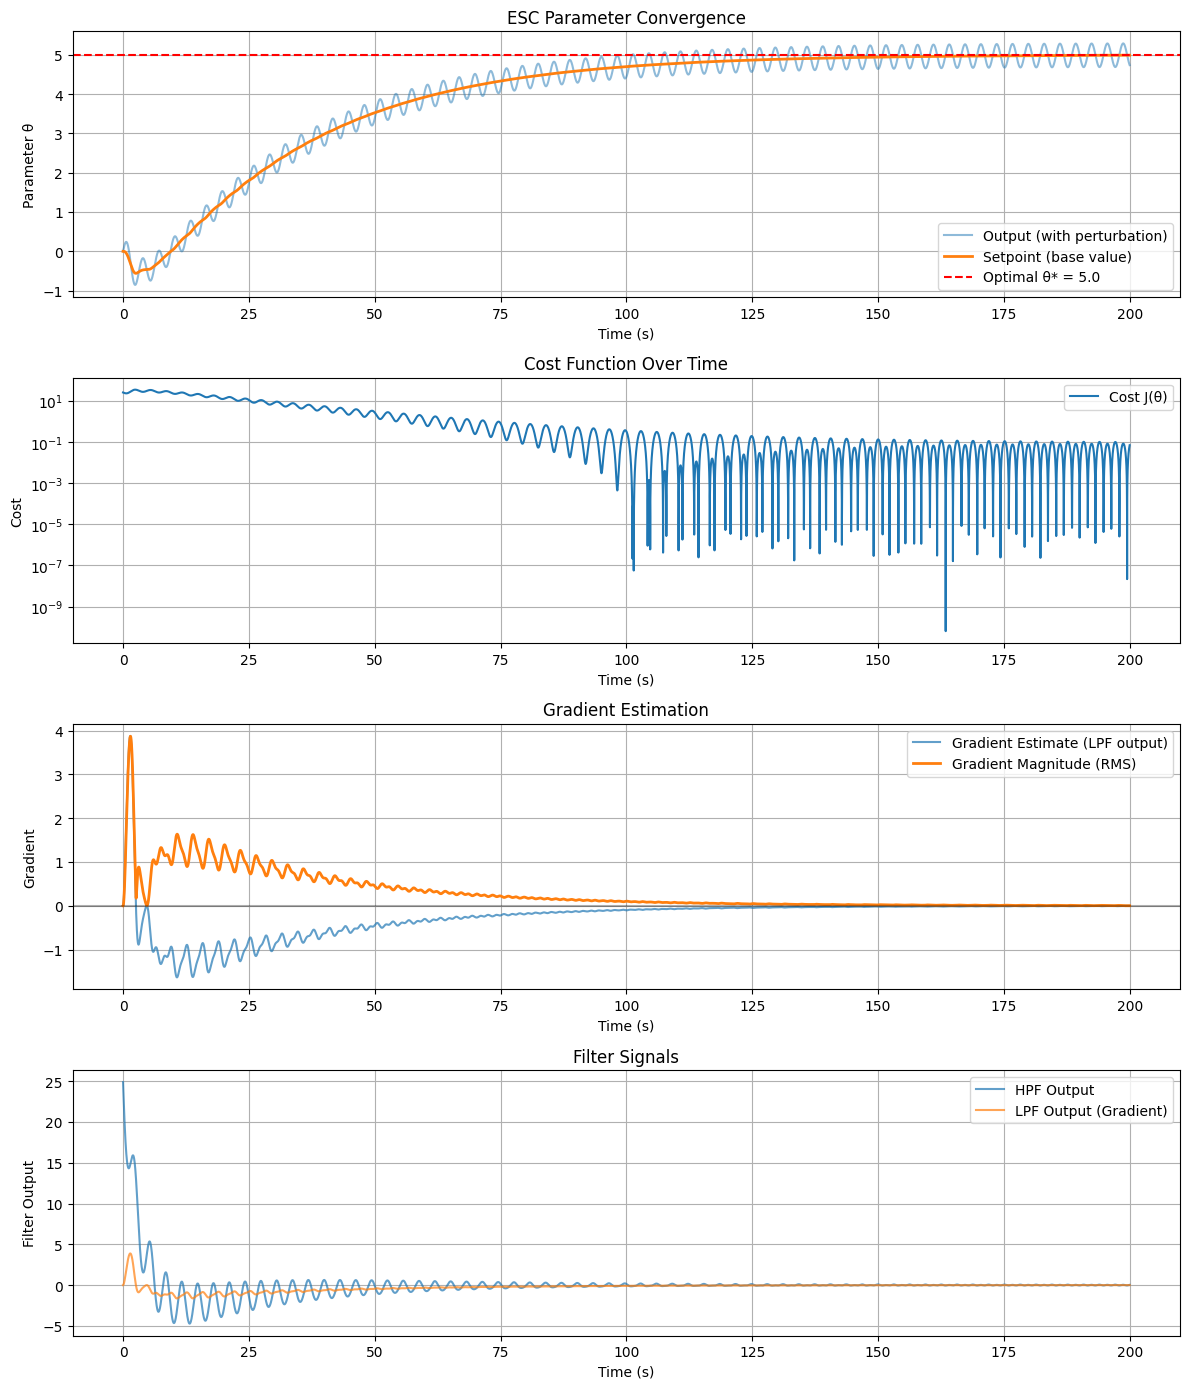


=== ESC Simulation Results ===
Optimal value (θ*): 5.0
Final setpoint: 4.9873
Final error: 0.0127
Final cost: 0.068393


In [6]:
# Plot results
fig, axes = plt.subplots(4, 1, figsize=(12, 14))

# Plot 1: Parameter convergence
axes[0].plot(t, outputs, label='Output (with perturbation)', alpha=0.5)
axes[0].plot(t, setpoints, label='Setpoint (base value)', linewidth=2)
axes[0].axhline(y=theta_star, color='r', linestyle='--', label=f'Optimal θ* = {theta_star}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Parameter θ')
axes[0].set_title('ESC Parameter Convergence')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Cost function
axes[1].plot(t, costs, label='Cost J(θ)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Cost')
axes[1].set_title('Cost Function Over Time')
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale('log')

# Plot 3: Gradient estimate and magnitude
axes[2].plot(t, lpf_outputs, label='Gradient Estimate (LPF output)', alpha=0.7)
axes[2].plot(t, gradient_magnitudes, label='Gradient Magnitude (RMS)', linewidth=2)
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Gradient')
axes[2].set_title('Gradient Estimation')
axes[2].legend()
axes[2].grid(True)

# Plot 4: Filter outputs
axes[3].plot(t, hpf_outputs, label='HPF Output', alpha=0.7)
axes[3].plot(t, lpf_outputs, label='LPF Output (Gradient)', alpha=0.7)
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Filter Output')
axes[3].set_title('Filter Signals')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

# Print final results
print(f"\n=== ESC Simulation Results ===")
print(f"Optimal value (θ*): {theta_star}")
print(f"Final setpoint: {setpoints[-1]:.4f}")
print(f"Final error: {abs(setpoints[-1] - theta_star):.4f}")
print(f"Final cost: {costs[-1]:.6f}")


In [7]:
class AdaptiveExtremumSeekingController:
    """
    Enhanced ESC with stability fixes:
    - Capped adaptive learning rate
    - Warmup period for RMSprop
    - Gradient-based vanishing perturbation
    """
    
    def __init__(
        self,
        sampling_period: float,
        dither_frequency: float,
        dither_amplitude: float,
        learning_rate: float,
        initial_value: float,
        high_pass_cutoff: float,
        low_pass_cutoff: float,
        min_output: float = -float('inf'),
        max_output: float = float('inf'),
        # Adaptive perturbation
        use_vanishing_perturbation: bool = True,
        min_perturbation_ratio: float = 0.1,
        # RMSprop
        use_rmsprop: bool = True,
        beta: float = 0.9,
        epsilon: float = 1e-8,
        max_lr_multiplier: float = 10.0,  # Cap adaptive LR
        # PI-ESC
        use_proportional: bool = True,
        proportional_gain: float = 0.1,
    ):
        self.dt = sampling_period
        self.omega = dither_frequency
        self.a_initial = dither_amplitude
        self.a = dither_amplitude
        self.k = learning_rate
        self.theta_0 = initial_value
        self.min_output = min_output
        self.max_output = max_output
        
        # Adaptive perturbation
        self.use_vanishing_perturbation = use_vanishing_perturbation
        self.min_perturbation = dither_amplitude * min_perturbation_ratio
        
        # RMSprop with stability
        self.use_rmsprop = use_rmsprop
        self.beta = beta
        self.epsilon = epsilon
        self.max_lr = learning_rate * max_lr_multiplier  # Cap the learning rate
        self.v = 0.0
        self.step_count = 0
        
        # PI-ESC
        self.use_proportional = use_proportional
        self.kp = proportional_gain
        
        # Filters
        self.hpf = HighPassFilter(sampling_period, high_pass_cutoff)
        self.lpf = LowPassFilter(sampling_period, low_pass_cutoff)
        
        # State
        self.phase = 0.0
        self.integral = 0.0
        
    def update(self, cost: float) -> dict:
        self.step_count += 1
        
        # 1. High-pass filter
        hpf_output = self.hpf.apply(cost)
        
        # 2. Demodulate (standard ESC without 2/a scaling to avoid amplification)
        demodulated = hpf_output * np.sin(self.phase)
        
        # 3. Low-pass filter -> gradient estimate
        gradient = self.lpf.apply(demodulated)
        
        # 4. RMSprop with stability measures
        if self.use_rmsprop:
            # Update variance estimate
            self.v = self.beta * self.v + (1.0 - self.beta) * (gradient ** 2)
            
            # Bias correction
            v_corrected = self.v / (1.0 - self.beta ** min(self.step_count, 1000))
            
            # Compute adaptive LR with cap
            raw_adaptive_lr = self.k / (np.sqrt(v_corrected) + self.epsilon)
            adaptive_lr = min(raw_adaptive_lr, self.max_lr)
        else:
            v_corrected = gradient ** 2
            adaptive_lr = self.k
        
        gradient_magnitude = np.sqrt(v_corrected + self.epsilon)
        
        # 5. PI control
        p_term = self.kp * gradient if self.use_proportional else 0.0
        
        # Integral with adaptive LR
        self.integral -= adaptive_lr * gradient * self.dt  # Negative for minimization
        
        # 6. Setpoint
        setpoint_raw = self.theta_0 + self.integral + p_term
        setpoint = np.clip(setpoint_raw, self.min_output, self.max_output)
        
        # Anti-windup
        if setpoint_raw != setpoint:
            self.integral = setpoint - self.theta_0 - p_term
        
        # 7. Vanishing perturbation based on gradient magnitude
        if self.use_vanishing_perturbation:
            # Scale perturbation with gradient magnitude
            # Large gradient -> full perturbation, small gradient -> reduced perturbation
            scale = np.tanh(gradient_magnitude)  # Smooth 0-1 scaling
            self.a = self.min_perturbation + (self.a_initial - self.min_perturbation) * scale
        
        # 8. Output with perturbation
        perturbation = self.a * np.sin(self.phase)
        output = np.clip(setpoint + perturbation, self.min_output, self.max_output)
        
        # 9. Update phase
        self.phase += self.omega * self.dt
        if self.phase > 2 * np.pi:
            self.phase -= 2 * np.pi
        
        return {
            'output': output,
            'setpoint': setpoint,
            'gradient': gradient,
            'gradient_magnitude': gradient_magnitude,
            'perturbation_amplitude': self.a,
            'adaptive_lr': adaptive_lr,
            'cost': cost,
        }
    
    def reset(self):
        self.hpf.reset()
        self.lpf.reset()
        self.phase = 0.0
        self.integral = 0.0
        self.v = 0.0
        self.step_count = 0
        self.a = self.a_initial


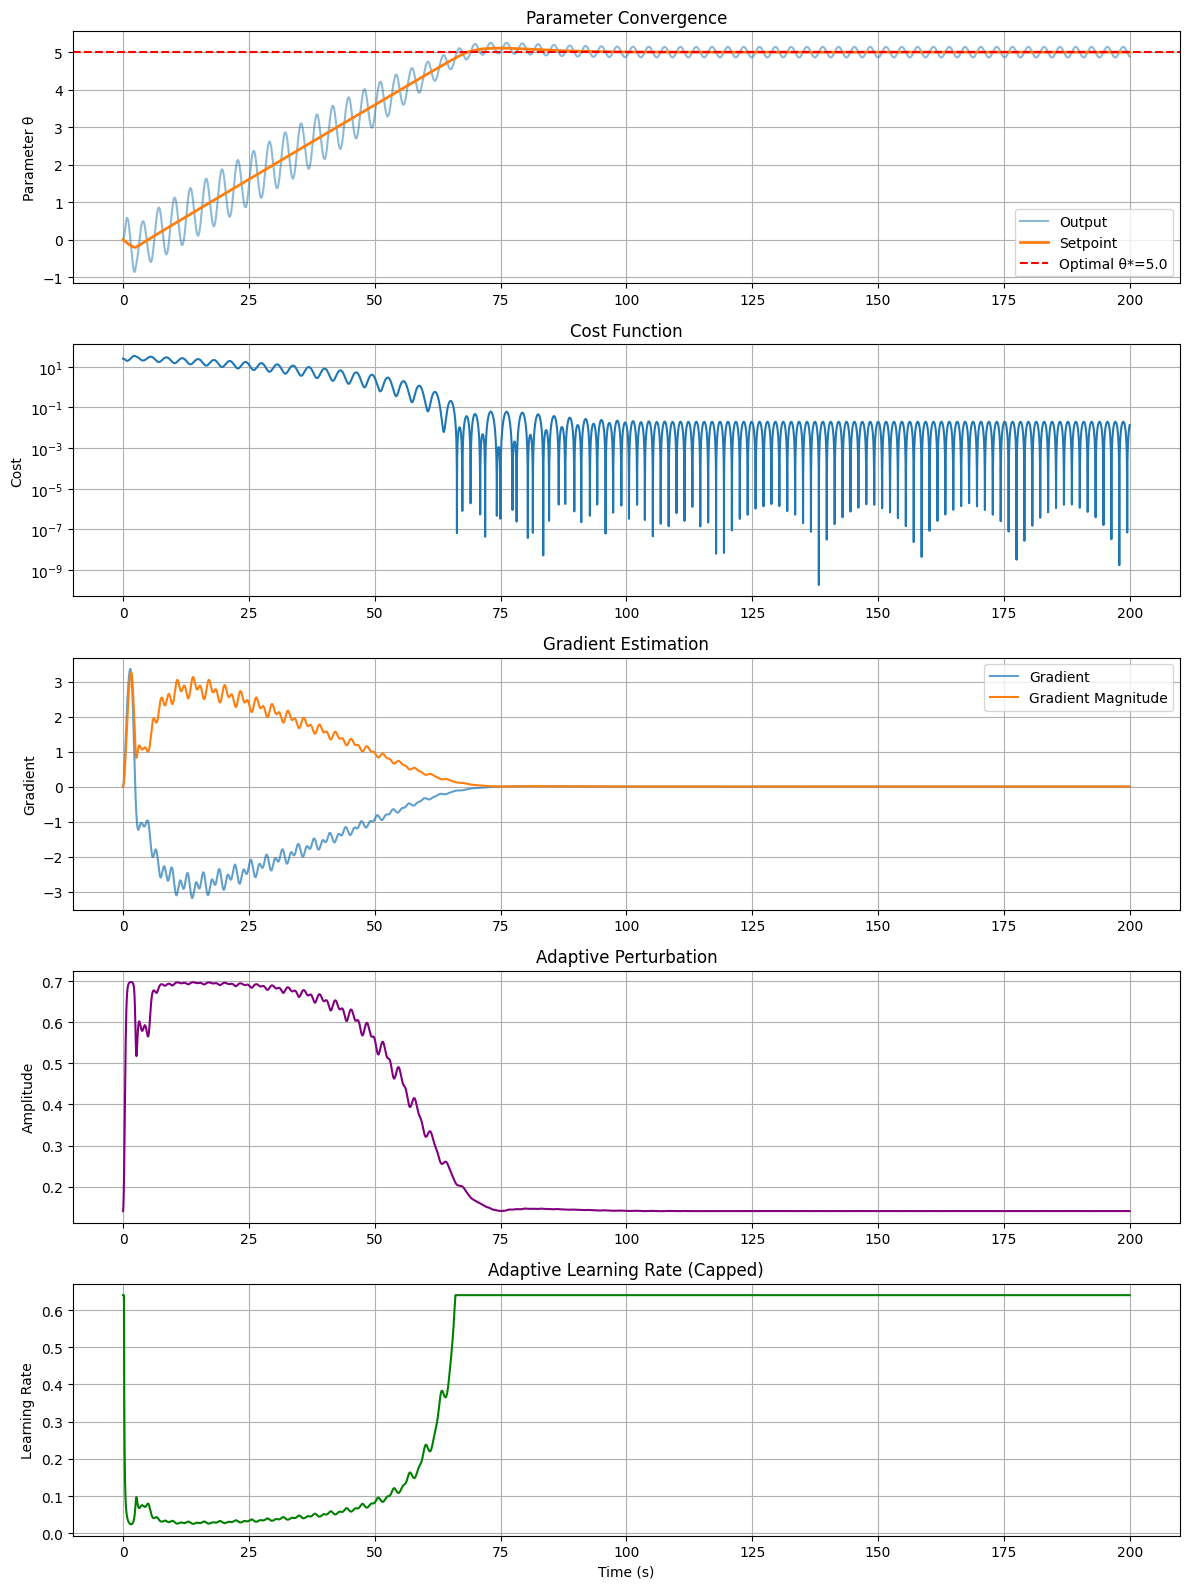

Final setpoint: 4.9998
Final cost: 0.013588


In [8]:
t_end = 200
dt = 0.01
t = np.arange(0, t_end, dt)
n_steps = len(t)

theta_star = 5.0
def cost_function(theta):
    return (theta - theta_star) ** 2

esc = AdaptiveExtremumSeekingController(
    sampling_period=dt,
    dither_frequency=2.0,
    dither_amplitude=0.7,
    learning_rate=0.08,           # Lower base LR
    initial_value=0.0,
    high_pass_cutoff=0.5,
    low_pass_cutoff=0.3,
    min_output=-10.0,
    max_output=20.0,
    use_vanishing_perturbation=True,
    min_perturbation_ratio=0.2,
    use_rmsprop=True,
    beta=0.95,                    # Higher beta = more smoothing
    max_lr_multiplier=8.0,        # Cap at 5x base LR
    use_proportional=False,       # Disable P term for stability
)

results = {key: np.zeros(n_steps) for key in 
           ['output', 'setpoint', 'gradient', 'gradient_magnitude', 
            'perturbation_amplitude', 'adaptive_lr', 'cost']}

cost = cost_function(esc.theta_0)

for i in range(n_steps):
    out = esc.update(cost)
    for key in results:
        results[key][i] = out[key]
    cost = cost_function(out['output'])

# Plot
fig, axes = plt.subplots(5, 1, figsize=(12, 16))

axes[0].plot(t, results['output'], alpha=0.5, label='Output')
axes[0].plot(t, results['setpoint'], linewidth=2, label='Setpoint')
axes[0].axhline(y=theta_star, color='r', linestyle='--', label=f'Optimal θ*={theta_star}')
axes[0].set_ylabel('Parameter θ')
axes[0].set_title('Parameter Convergence')
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy(t, results['cost'])
axes[1].set_ylabel('Cost')
axes[1].set_title('Cost Function')
axes[1].grid(True)

axes[2].plot(t, results['gradient'], alpha=0.7, label='Gradient')
axes[2].plot(t, results['gradient_magnitude'], label='Gradient Magnitude')
axes[2].set_ylabel('Gradient')
axes[2].set_title('Gradient Estimation')
axes[2].legend()
axes[2].grid(True)

axes[3].plot(t, results['perturbation_amplitude'], color='purple')
axes[3].set_ylabel('Amplitude')
axes[3].set_title('Adaptive Perturbation')
axes[3].grid(True)

axes[4].plot(t, results['adaptive_lr'], color='green')
axes[4].set_ylabel('Learning Rate')
axes[4].set_xlabel('Time (s)')
axes[4].set_title('Adaptive Learning Rate (Capped)')
axes[4].grid(True)

plt.tight_layout()
plt.show()

print(f"Final setpoint: {results['setpoint'][-1]:.4f}")
print(f"Final cost: {results['cost'][-1]:.6f}")


In [12]:
# -- Maximum Seeking Controller --

class MaximizingExtremumSeekingController:
    """
    ESC for REWARD MAXIMIZATION (MARL-style).
    
    Key differences from minimization:
    - Integrates gradient with POSITIVE sign (gradient ascent)
    - Works with unknown optimal reward value
    - Uses relative reward changes, not absolute values
    """
    
    def __init__(
        self,
        sampling_period: float,
        dither_frequency: float,
        dither_amplitude: float,
        learning_rate: float,
        initial_value: float,
        high_pass_cutoff: float,
        low_pass_cutoff: float,
        min_output: float = -float('inf'),
        max_output: float = float('inf'),
        # Adaptive perturbation
        use_vanishing_perturbation: bool = True,
        min_perturbation_ratio: float = 0.1,
        # RMSprop
        use_rmsprop: bool = True,
        beta: float = 0.9,
        epsilon: float = 1e-8,
        max_lr_multiplier: float = 10.0,
    ):
        self.dt = sampling_period
        self.omega = dither_frequency
        self.a_initial = dither_amplitude
        self.a = dither_amplitude
        self.k = learning_rate
        self.theta_0 = initial_value
        self.min_output = min_output
        self.max_output = max_output
        
        # Adaptive perturbation
        self.use_vanishing_perturbation = use_vanishing_perturbation
        self.min_perturbation = dither_amplitude * min_perturbation_ratio
        
        # RMSprop
        self.use_rmsprop = use_rmsprop
        self.beta = beta
        self.epsilon = epsilon
        self.max_lr = learning_rate * max_lr_multiplier
        self.v = 0.0
        self.step_count = 0
        
        # Filters
        self.hpf = HighPassFilter(sampling_period, high_pass_cutoff)
        self.lpf = LowPassFilter(sampling_period, low_pass_cutoff)
        
        # State
        self.phase = 0.0
        self.integral = 0.0
        
    def update(self, reward: float) -> dict:
        """
        Update with reward signal (MAXIMIZATION).
        
        Args:
            reward: Current reward value (higher = better)
        """
        self.step_count += 1
        
        # 1. High-pass filter removes DC offset (unknown baseline reward)
        # This is KEY for unknown optimal reward - we only care about CHANGES
        hpf_output = self.hpf.apply(reward)
        
        # 2. Demodulate
        demodulated = hpf_output * np.sin(self.phase)
        
        # 3. Low-pass filter -> gradient estimate
        gradient = self.lpf.apply(demodulated)
        
        # 4. RMSprop
        if self.use_rmsprop:
            self.v = self.beta * self.v + (1.0 - self.beta) * (gradient ** 2)
            v_corrected = self.v / (1.0 - self.beta ** min(self.step_count, 1000))
            raw_adaptive_lr = self.k / (np.sqrt(v_corrected) + self.epsilon)
            adaptive_lr = min(raw_adaptive_lr, self.max_lr)
        else:
            v_corrected = gradient ** 2
            adaptive_lr = self.k
        
        gradient_magnitude = np.sqrt(v_corrected + self.epsilon)
        
        # 5. GRADIENT ASCENT (positive sign for maximization!)
        self.integral += adaptive_lr * gradient * self.dt
        
        # 6. Setpoint
        setpoint_raw = self.theta_0 + self.integral
        setpoint = np.clip(setpoint_raw, self.min_output, self.max_output)
        
        # Anti-windup
        if setpoint_raw != setpoint:
            self.integral = setpoint - self.theta_0
        
        # 7. Vanishing perturbation
        if self.use_vanishing_perturbation:
            scale = np.tanh(gradient_magnitude)
            self.a = self.min_perturbation + (self.a_initial - self.min_perturbation) * scale
        
        # 8. Output
        perturbation = self.a * np.sin(self.phase)
        output = np.clip(setpoint + perturbation, self.min_output, self.max_output)
        
        # 9. Update phase
        self.phase += self.omega * self.dt
        if self.phase > 2 * np.pi:
            self.phase -= 2 * np.pi
        
        return {
            'demodulated': demodulated,
            'hf': hpf_output,
            'output': output,
            'setpoint': setpoint,
            'gradient': gradient,
            'gradient_magnitude': gradient_magnitude,
            'perturbation_amplitude': self.a,
            'adaptive_lr': adaptive_lr,
        }
    
    def reset(self):
        self.hpf.reset()
        self.lpf.reset()
        self.phase = 0.0
        self.integral = 0.0
        self.v = 0.0
        self.step_count = 0
        self.a = self.a_initial


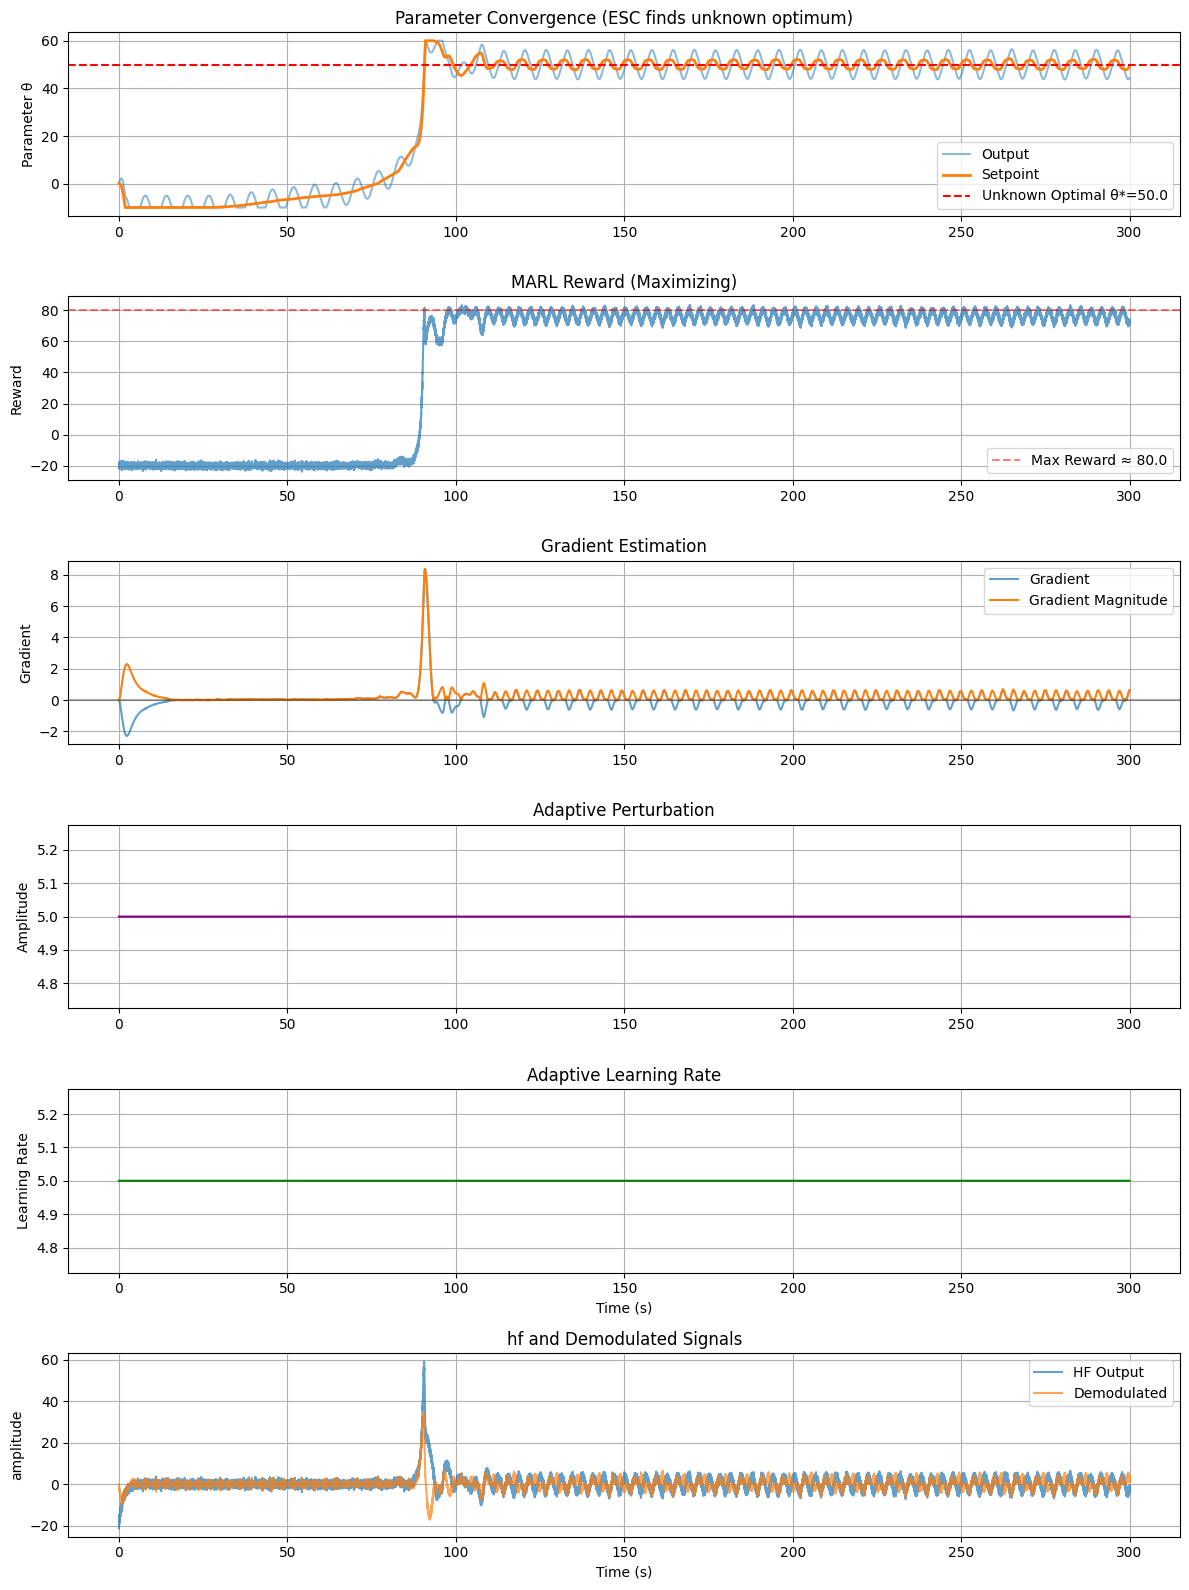


=== MARL-style ESC Results ===
Unknown optimal θ*: 50.0
Final setpoint: 49.3552
Discovery error: 0.6448
Final reward: 73.29
Max possible reward: ~80.00


In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation
t_end = 300
dt = 0.01
t = np.arange(0, t_end, dt)
n_steps = len(t)

# MARL-style reward function
# - We DON'T know theta_star or max_reward
# - ESC must find it through exploration
theta_star = 50.0  # Unknown to controller
max_reward = 100.0  # Unknown to controller

def reward_function(theta):
    # Wider Gaussian (σ=15 instead of 2)
    base_reward = max_reward * np.exp(-0.5 * ((theta - theta_star) / 15.0) ** 2)
    noise = np.random.normal(0, 1.0)
    return base_reward - 20 + noise


# Alternative: More realistic MARL reward with sparse signal
def sparse_reward_function(theta):
    """Sparse reward - only high reward near optimum."""
    distance = abs(theta - theta_star)
    if distance < 1.0:
        return 50 + np.random.normal(0, 2)
    elif distance < 3.0:
        return 10 + np.random.normal(0, 2)
    else:
        return -5 + np.random.normal(0, 2)

# Initialize ESC for MAXIMIZATION
esc = MaximizingExtremumSeekingController(
    sampling_period=dt,
    dither_frequency=1.0,
    dither_amplitude=5.0,         # Larger for exploration
    learning_rate=5,
    initial_value=0.0,            # Start far from unknown optimum
    high_pass_cutoff=0.8,
    low_pass_cutoff=0.25,
    min_output=-10.0,
    max_output=60.0,
    use_vanishing_perturbation=False,
    min_perturbation_ratio=0.0,
    use_rmsprop=False,
    beta=0.8,
    max_lr_multiplier=10.0,
)

# Storage
results = {key: np.zeros(n_steps) for key in 
           ['demodulated', 'hf','output', 'setpoint', 'gradient', 'gradient_magnitude', 
            'perturbation_amplitude', 'adaptive_lr', 'reward']}

# Run simulation
reward = reward_function(esc.theta_0)
# reward = np.tanh(reward / 20.0)


for i in range(n_steps):
    out = esc.update(reward)
    for key in results:
        if key != 'reward':
            results[key][i] = out[key]
    results['reward'][i] = reward
    reward = reward_function(out['output'])

# Plot
fig, axes = plt.subplots(6, 1, figsize=(12, 16))

# 1. Parameter convergence
axes[0].plot(t, results['output'], alpha=0.5, label='Output')
axes[0].plot(t, results['setpoint'], linewidth=2, label='Setpoint')
axes[0].axhline(y=theta_star, color='r', linestyle='--', label=f'Unknown Optimal θ*={theta_star}')
axes[0].set_ylabel('Parameter θ')
axes[0].set_title('Parameter Convergence (ESC finds unknown optimum)')
axes[0].legend()
axes[0].grid(True)

# 2. Reward (not cost!)
axes[1].plot(t, results['reward'], alpha=0.7)
axes[1].axhline(y=max_reward - 20, color='r', linestyle='--', alpha=0.5, label=f'Max Reward ≈ {max_reward-20}')
axes[1].set_ylabel('Reward')
axes[1].set_title('MARL Reward (Maximizing)')
axes[1].legend()
axes[1].grid(True)

# 3. Gradient
axes[2].plot(t, results['gradient'], alpha=0.7, label='Gradient')
axes[2].plot(t, results['gradient_magnitude'], label='Gradient Magnitude')
axes[2].axhline(y=0, color='k', alpha=0.3)
axes[2].set_ylabel('Gradient')
axes[2].set_title('Gradient Estimation')
axes[2].legend()
axes[2].grid(True)

# 4. Perturbation
axes[3].plot(t, results['perturbation_amplitude'], color='purple')
axes[3].set_ylabel('Amplitude')
axes[3].set_title('Adaptive Perturbation')
axes[3].grid(True)

# 5. Learning rate
axes[4].plot(t, results['adaptive_lr'], color='green')
axes[4].set_ylabel('Learning Rate')
axes[4].set_xlabel('Time (s)')
axes[4].set_title('Adaptive Learning Rate')
axes[4].grid(True)

axes[5].plot(t, results['hf'], alpha=0.7, label='HF Output')
axes[5].plot(t, results['demodulated'], alpha=0.7, label='Demodulated')
axes[5].set_ylabel('amplitude')
axes[5].set_xlabel('Time (s)')
axes[5].set_title('hf and Demodulated Signals')
axes[5].legend()
axes[5].grid(True)

plt.tight_layout()
plt.show()

# Results
print(f"\n=== MARL-style ESC Results ===")
print(f"Unknown optimal θ*: {theta_star}")
print(f"Final setpoint: {results['setpoint'][-1]:.4f}")
print(f"Discovery error: {abs(results['setpoint'][-1] - theta_star):.4f}")
print(f"Final reward: {results['reward'][-1]:.2f}")
print(f"Max possible reward: ~{max_reward - 20:.2f}")


In [11]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")


/home/svarp/miniconda3/envs/ad2c/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
CUDA device count: 1
